In [7]:
%pip install numpy
import numpy as np

In [8]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


total number of deployed SNs: 100
Time: 0.0
Node 1: [112.68900296270948, 40.0]
Node 2: [16.19632363814403, 40.0]
Node 3: [129.21499374540826, 40.0]
Node 4: [120.87045040740752, 40.0]
Node 5: [93.33834907960198, 40.0]
Node 6: [105.71856290674343, 40.0]
Node 7: [86.46339282030345, 40.0]
Node 8: [26.175845119531647, 40.0]
Node 9: [66.7053945978966, 40.0]
Node 10: [147.89835319887632, 40.0]
Node 11: [138.11253242273378, 40.0]
Node 12: [80.33547874066302, 40.0]
Node 13: [100.15688195709137, 40.0]
Node 14: [11.518888563571956, 40.0]
Node 15: [35.09765070961745, 40.0]
Node 16: [127.94508120231733, 40.0]
Node 17: [45.81653555677031, 40.0]
Node 18: [92.7091925753347, 40.0]
Node 19: [6.548218830320478, 40.0]
Node 20: [156.08450004508316, 40.0]
Node 21: [61.78706541277885, 40.0]
Node 22: [85.77799442484435, 40.0]
Node 23: [161.87377234940718, 40.0]
Node 24: [16.862370822455826, 40.0]
Node 25: [50.845814782784515, 40.0]
Node 26: [73.23677149478603, 40.0]
Node 27: [149.48070703241677, 40.0]
Node 28

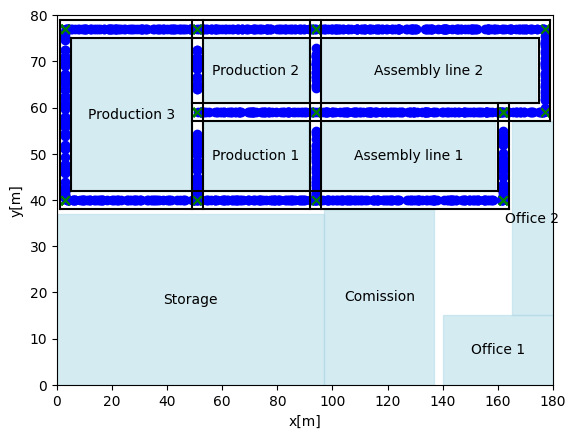

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import random
import matplotlib.patches as patches
import pandas as pd


#Define room sizes
room_properties = {
    "Storage": {"size":(97, 37), "color": "lightblue", "position":(0,0)},
    "Comission": {"size":(40, 38), "color": "lightblue", "position":(97,0)},
    "Office 1": {"size":(40, 15), "color": "lightblue", "position":(140,0)},
    "Office 2": {"size":(15, 42), "color": "lightblue", "position":(165,15)},
    "Production 3": {"size":(44, 33), "color": "lightblue", "position":(5,42)},
    "Production 2": {"size":(38, 14), "color": "lightblue", "position":(53,61)},
    "Production 1": {"size":(38, 15), "color": "lightblue", "position":(53,42)},
    "Assembly line 1": {"size":(63, 15), "color": "lightblue", "position":(96,42)},
    "Assembly line 2": {"size":(78, 14), "color": "lightblue", "position":(96,61)},
}

#Create figure and axis
fig, ax = plt.subplots()

#Plot rooms
for room, properties in room_properties.items():
    size = properties["size"]
    color = properties["color"]
    position = properties["position"]
    
    width, height = size
    x,y = position
    
    ax.add_patch(plt.Rectangle((x,y), width, height, color=color, alpha=0.5))
    ax.text(x + width / 2, y + height / 2, room.capitalize(), ha='center', va='center')
   # x_offset += width 
    
# Define lanes between blocks
lanes = [
    # Lanes 
    [(1, 79), (179, 79)],
    [(1, 38), (1, 79)],
    [(1, 38), (164, 38)],
    [(179, 79), (179, 57)],
    [(49, 57), (179, 57)],
    [(5, 75), (175, 75)],
    [(5, 75), (5, 42)],
    [(5, 42), (160, 42)],
    [(175, 75), (175, 61)],
    [(49, 61), (175, 61)],
    [(49, 79), (49, 38)],
    [(53, 79), (53, 38)],
    [(92, 79), (92, 38)],
    [(96, 79), (96, 38)],
    [(164, 61), (164, 38)],   
    [(160, 61), (160, 42)],
]
    
# Plot lanes
for lane in lanes:
    x_values, y_values = zip(*lane)
    ax.plot(x_values, y_values, color='black', linestyle='-')
    
#deployment of restricted area and min distance
def deployment(n_points, restricted_area, min_dist, cell_radius):
    width, height = restricted_area[0],restricted_area[1]
    
    x_supp = [cell_radius + width[0], width[1] - cell_radius]
    y_supp = [cell_radius + height[0], height[1] - cell_radius]
    node_loc = np.zeros((n_points, 2))
    
    for i in range(n_points):
        node_loc[i,0] = np.random.uniform(x_supp[0], x_supp[1])
        node_loc[i,1] = np.random.uniform(y_supp[0], y_supp[1])
        
        #Euclidean distance(check cell radius and min distance)
        for j in range(i):
            if (np.linalg.norm(node_loc[i]-node_loc[j]) < min_dist):
                    node_loc[i,0] = np.random.uniform(x_supp[0], x_supp[1])
                    node_loc[i,1] = np.random.uniform(y_supp[0], y_supp[1])
                    for m in range(i):
                        if(np.linalg.norm(node_loc[i] - node_loc[m]) < min_dist):
                            node_loc[i,0] = np.random.uniform(x_supp[0], x_supp[1])
                            node_loc[i,1] = np.random.uniform(y_supp[0], y_supp[1])
    return node_loc

def collision_test(subnet_location, traffic_light_v1, traffic_light_v5, traffic_light_h1, traffic_light_h3, cell_radius, velocity, t):
    if (subnet_location[0] < 1):
        if (subnet_location[1] < 38):
            movement = np.pi/2
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.cos(movement)
        elif (subnet_location[1] > 79):
            movement = 0
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.cos(movement)
        else:
            movement = np.pi/2
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.cos(movement)
    elif (subnet_location[0] > 179):
        if (subnet_location[1]  < 57):
            movement = -np.pi
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)
        elif (subnet_location[1]  > 79):
            movement = -np.pi/2
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)  
        else:    
            movement = -np.pi/2
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)   
    elif (subnet_location[0] > 164):
        if (subnet_location[1] < 38):
            movement = -np.pi
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)
        else:
            probabilities = [0.5, 0.25]
            choices = [-np.pi/2, -np.pi]
            movement = random.choices(choices, weights=probabilities, k=1)[0]
            subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
            subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)
    #y
    elif (subnet_location[1] > 79):
            if (subnet_location[0] < 1):
                movement = 0
                subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)
            elif (subnet_location[0] > 179):
                movement = -np.pi/2
                subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)  
            else:
                min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location)-np.array(traffic_light_h3[jj])) for jj in range(len(traffic_light_h3))])
                if np.linalg.norm(np.array(subnet_location)-np.array(traffic_light_h3[min_traffic_distance_index])) < cell_radius:
                    probabilities = [0.5, 0.25]
                    choices =[0, -np.pi/2]
                    movement = random.choices(choices, weights=probabilities, k=1)[0]
                    subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                    subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)
                else:    
                    movement = 0
                    subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                    subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)    
    elif (subnet_location[1] < 38):
            if (subnet_location[0] > 164):
                movement = -np.pi
                subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)
            elif (subnet_location[0] <1):
                movement = np.pi/2
                subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)  
            else:
                min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location)-np.array(traffic_light_h1[jj])) for jj in range(len(traffic_light_h1))])
                if np.linalg.norm(np.array(subnet_location)-np.array(traffic_light_h1[min_traffic_distance_index])) < cell_radius:
                    probabilities = [0.5, 0.25]
                    choices =[-np.pi, np.pi/2]
                    movement = random.choices(choices, weights=probabilities, k=1)[0]
                    subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                    subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)
                else:    
                    movement = -np.pi
                    subnet_location[0] = subnet_location[0]+velocity*t*np.cos(movement)
                    subnet_location[1] = subnet_location[1]+velocity*t*np.sin(movement)          

    return subnet_location    

def subnet_movement(subnet_location,traffic_light_h1,traffic_light_h2,traffic_light_h3,traffic_light_v1,traffic_light_v2,traffic_light_v3,traffic_light_v4,traffic_light_v5,cell_radius,velocity, t):
    for i in range(len(subnet_location)):
        #horizental
        if np.all(1 <= subnet_location[i][0] <= 164) and np.all(38 <= subnet_location[i][1] <= 42):
            min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_h1[jj])) for jj in range(len(traffic_light_h1))])
            if np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_h1[min_traffic_distance_index])) < cell_radius:
                choices =[-np.pi,np.pi/2]
                probabilities = [0.5, 0.5]
                movement = random.choices(choices, weights=probabilities, k=1)[0]
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
            else:
                movement = -np.pi
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
        elif np.all(49 <= subnet_location[i][0] <= 179) and np.all(57 <= subnet_location[i][1] <= 61):
            min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_h2[jj])) for jj in range(len(traffic_light_h2))])
            if np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_h2[min_traffic_distance_index])) < cell_radius:
                choices =[-np.pi, -np.pi/2, np.pi/2]
                probabilities = [0.5, 0.25, 0.25]
                movement = random.choices(choices, weights=probabilities, k=1)[0]
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
            else:
                movement = -np.pi
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
        elif np.all(1 <= subnet_location[i][0] <= 179) and np.all(75 <= subnet_location[i][1] <= 79):
            min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_h3[jj])) for jj in range(len(traffic_light_h3))])
            if np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_h3[min_traffic_distance_index])) < cell_radius:
                choices =[0, -np.pi/2]
                probabilities = [0.5, 0.5]
                movement = random.choices(choices, weights=probabilities, k=1)[0]
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
            else:
                movement = 0
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)

        #vertical
        if np.all(1 <= subnet_location[i][0] <= 5) and np.all(38 <= subnet_location[i][1] <= 79):
            min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v1[jj])) for jj in range(len(traffic_light_v1))])
            if np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v1[min_traffic_distance_index])) < cell_radius:
                choices =[0, np.pi/2]
                probabilities = [0.25, 0.5]
                movement = random.choices(choices, weights=probabilities, k=1)[0]
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
            else:
                movement = np.pi/2
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
        if np.all(49 <= subnet_location[i][0] <= 53) and np.all(38 <= subnet_location[i][1] <= 79):
            min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v2[jj])) for jj in range(len(traffic_light_v2))])
            if np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v2[min_traffic_distance_index])) < cell_radius:
                choices =[0, np.pi/2]
                probabilities = [0.5, 0.5]
                movement = random.choices(choices, weights=probabilities, k=1)[0]
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
            else:
                movement = np.pi/2
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
        elif np.all(92 <= subnet_location[i][0] <= 96) and np.all(38 <= subnet_location[i][1] <= 79):
            min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v3[jj])) for jj in range(len(traffic_light_v3))])
            if np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v3[min_traffic_distance_index])) < cell_radius:
                choices =[np.pi/2, 0, -np.pi]
                probabilities = [0.5, 0.25, 0.25]
                movement = random.choices(choices, weights=probabilities, k=1)[0]
                subnet_location[i][0] = subnet_location[i][0]+ velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+ velocity*t*np.sin(movement)
            else:
                movement = np.pi/2
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
        elif np.all(160 <= subnet_location[i][0] <= 164) and np.all(38 <= subnet_location[i][1] <= 61):
            min_traffic_distance_index = np.argmin([np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v4[jj])) for jj in range(len(traffic_light_v4))])
            if np.linalg.norm(np.array(subnet_location[i])-np.array(traffic_light_v4[min_traffic_distance_index])) < cell_radius:
                choices =[-np.pi/2, 0, -np.pi]
                probabilities = [0.5, 0.25, 0.25]
                movement = random.choices(choices, weights=probabilities, k=1)[0]
                subnet_location[i][0] = subnet_location[i][0]+ velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+ velocity*t*np.sin(movement)
            else:
                movement = -np.pi/2
                subnet_location[i][0] = subnet_location[i][0]+velocity*t*np.cos(movement)
                subnet_location[i][1] = subnet_location[i][1]+velocity*t*np.sin(movement)
        elif np.all(179 < subnet_location[i][0] <= 180 or 0 < subnet_location[i][0] <= 1 or 79 <= subnet_location[i][1] <= 80 or 0 < subnet_location[i][1] <= 38):
            subnet_location[i] = collision_test(subnet_location[i],traffic_light_v1,traffic_light_v5,traffic_light_h1,traffic_light_h3,cell_radius,velocity,t)


# Define time values 
time_values = np.linspace(0, 1, num=10)  # Adjust the number of time steps as needed
#velocity = 2

#subnet_location = {}
# Create an empty list to store positions at each time instance
positions_over_time = []

# Initialize the previous position to the initial position
previous_position = subnet_location.copy()

# Iterate over time values
for t in time_values:
    def mobility_setup(n_points,cell_radius,min_dist):
        height = [[38,42],[57,61],[75,79],[38,79],[38,57],[62,75],[38,57],[62,75],[38,57],[57,79]]
        width = [[1,164],[49,179],[1,179],[1,5],[49,53],[49,53],[92,96],[92,96],[160,164],[175,179]]
        restricted_area = [[[w[0],w[1]], [h[0],h[1]]] for h, w in zip(height, width)]     

        ratio = [np.abs((width[j][1]-width[j][0])*(height[j][1]-height[j][0]))/np.sum([np.abs((width[i][1]-width[i][0])*(height[i][1]-height[i][0])) for i in range(len(restricted_area))])for j in range(len(restricted_area))]
        num_sn = np.array(n_points*np.array(ratio),dtype=int)
        print("total number of deployed SNs:",np.sum(num_sn))
        all_sn_position = []
        lane_width  = 5
        for kk in range(len(num_sn)):
            node_loc =  deployment(num_sn[kk], restricted_area[kk], min_dist, cell_radius)
            all_sn_position.append(node_loc)
        x_axis = [all_sn_position[ii][j][0]  for ii in range(len(all_sn_position)) for j in range(len(all_sn_position[ii]))]
        y_axis  = [all_sn_position[ii][j][1]  for ii in range(len(all_sn_position)) for j in range(len(all_sn_position[ii]))]
        subnet_location  = [[x_axis[i],y_axis[i]] for i in range(len(x_axis))]
        #subnet_location = [[x, y] for x, y in zip(x_axis, y_axis)]

        traffic_light_h1 = [[3,40],[51,40],[94,40],[162,40]]
        traffic_light_h2 = [[51,59],[94,59],[162,59],[177,59]]
        traffic_light_h3 = [[3,77],[51,77],[94,77],[177,77]]

        traffic_light_v1 = [[3,40],[3,77]]
        traffic_light_v2 = [[51,40],[51,59],[51,77]]
        traffic_light_v3 = [[94,40],[94,59],[94,77]]
        traffic_light_v4 = [[162,40],[162,59]]
        traffic_light_v5 = [[177,59],[177,77]]

        return subnet_location, traffic_light_h1, traffic_light_h2, traffic_light_h3, traffic_light_v1, traffic_light_v2, traffic_light_v3, traffic_light_v4, traffic_light_v5
    
     
    # Call mobility_setup to get parameters
    subnet_location, traffic_light_h1, traffic_light_h2, traffic_light_h3, traffic_light_v1, traffic_light_v2, traffic_light_v3, traffic_light_v4, traffic_light_v5 = mobility_setup(n_points=104, cell_radius=2, min_dist=4)

    # Define parameters for plotting
    rectangles = [
        [[0, 180], [0, 38]],
        [[0, 180], [79, 80]],
        # Add more rectangles for other restricted areas if needed
    ]


    # Plot nodes
    plt.scatter([loc[0] for loc in subnet_location], [loc[1] for loc in subnet_location], color='blue', label='Nodes')

    # Plot traffic lights
    for light in [traffic_light_h1, traffic_light_h2, traffic_light_h3, traffic_light_v1, traffic_light_v4]:
        plt.scatter([loc[0] for loc in light], [loc[1] for loc in light], color='green', marker='x', label='Traffic Lights')


    # Adjust pandas display options
    pd.set_option('display.max_rows', None)  # Set to None to display all rows
    pd.set_option('display.max_columns', None)  # Set to None to display all columns

    # Extract x and y coordinates of the nodes from subnet_location
    x_coordinates = [loc[0] for loc in subnet_location]
    y_coordinates = [loc[1] for loc in subnet_location]

    # Create a DataFrame to hold the coordinates
    data = {
        'X Coordinate': x_coordinates,
        'Y Coordinate': y_coordinates
    }
    df = pd.DataFrame(data)

    # Set the index to start from 1 instead of 0
    df.index = df.index + 1

    # Print the DataFrame
    #print("Node Coordinates:")
    #print(df)
    # Calculate the change in position since the previous time step
    position_change = np.array(subnet_location) - np.array(previous_position)
    
    # Store the change in position and the current time instance
    positions_over_time.append((t, position_change))
    
    print(f"Time: {t}")
    for i, position in enumerate(subnet_location):
        print(f"Node {i + 1}: {position}")
        
    # Update the previous position for the next iteration
    previous_position = subnet_location.copy()
     

    # Set axis labels
    ax.set_xlim(0, 180)
    ax.set_ylim(0, 80)
    ax.set_xlabel('x[m]')
    ax.set_ylabel('y[m]')

# Show plot
plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt

def path_loss(x, y, alpha):
    '''
    non singulat distance dependent path loss is utilized :
    https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=8697126    eq(4)
    loss exponent(alpha>2)
    '''
    return min(1, np.linalg.norm(y-x)**(-alpha))



def small_scale_fading(t, M, doppler, beta_n, theta):
    '''
    modified jakes fading  is utilized
    reason: to generate uncorrelated fading waveforms.
    https://www.ee.iitm.ac.in/~giri/pdfs/EE5141/EE5141/Jakes-model-revisited.pdf eq:2
    '''
    H = np.abs(np.sqrt(2/M)*(np.sum((np.cos(beta_n)+1j*np.sin(beta_n))*np.cos(doppler*t+theta))))
    return H**2



#shadowing effect
def createMap(width, height, sigmaS, correlationDistance, stepsize):
    '''
    Book :“Stochastic Geometry, Spatial Statistics and Random Fields:,”, page 374 
    '''
    num_x_points = int(width/stepsize) + 3
    num_y_points = int(height/stepsize) + 3
    mapXPoints=np.linspace(0, width, num=num_x_points, endpoint=True)
    mapYPoints=np.linspace(0, height, num=num_y_points, endpoint=True)
    
    N1 = len(mapXPoints)
    N2 = len(mapYPoints)
    G = np.zeros([N1,N2],dtype=np.float64)
    for n in range(N1):
        for m in range(N2):
            G[n,m]= sigmaS*np.exp(-1*np.sqrt(np.min([np.absolute(mapXPoints[0]-mapXPoints[n]),\
                                      width-np.absolute(mapXPoints[0]-mapXPoints[n])])**2\
            + np.min([np.absolute(mapYPoints[0]-mapYPoints[m]),height\
                  -np.absolute(mapYPoints[0]-mapYPoints[m])])**2)/correlationDistance)
    Gamma = np.fft.fft2(G)
    Z = np.random.randn(N1,N2) + 1j*np.random.randn(N1,N2)
    mapp = np.real(np.fft.fft2(np.multiply(np.sqrt(Gamma),Z)\
                               /np.sqrt(N1*N2)))
    return mapp


def shadowing(grf, delta, loc1, loc2, stepsize, height, width):
    grf1 = grf[int((loc1[0]+width/2)/stepsize)+1][int((loc1[1]+height/2)/stepsize)+1]
    grf2 = grf[int((loc2[0]+width/2)/stepsize)+1][int((loc2[1]+height/2)/stepsize)+1]
    dist = np.linalg.norm(loc1-loc2)
    return 10**(((1-np.exp(-dist/delta))/(np.sqrt(2)*np.sqrt(1+np.exp(-dist/delta)))*(grf1+grf2))/10)


def interference_power(kappa, x_0, x, alpha, t, theta, M, doppler, beta_n, grf, delta, stepsize, height, width):
    path_l = path_loss(x_0, x, alpha)
    ss_fading = small_scale_fading(t, M, doppler, beta_n, theta)
    shadow = shadowing(grf, delta, x, x_0, stepsize, height, width)
    interference = path_l * ss_fading * shadow
    return interference


def interference_power_med_resten(kappa, x_0, x, alpha, t, theta, M, doppler, beta_n, grf, delta, stepsize, height, width):
    path_l = path_loss(x_0, x, alpha)
    ss_fading = small_scale_fading(t, M, doppler, beta_n, theta)
    shadow = shadowing(grf, delta, x, x_0, stepsize, height, width)
    interference = path_l * ss_fading * shadow
    return interference, path_l, ss_fading, shadow

In [2]:
%pip install subnetwork_channel

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement subnetwork_channel (from versions: none)
ERROR: No matching distribution found for subnetwork_channel


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from subnetwork_channel import path_loss, small_scale_fading , createMap, shadowing 
from tqdm import tqdm

ModuleNotFoundError: No module named 'subnetwork_channel'

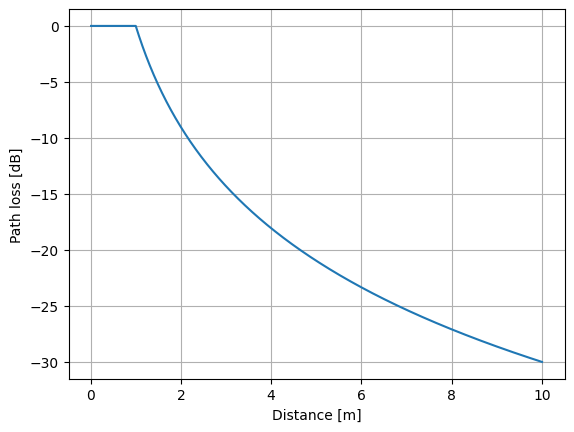

In [35]:
if __name__ == '__main__':
    #path loss plot
    x = np.linspace(0.01,10,1000)
    y = np.linspace(0.02,20,1000)
    alpha = 3

    path_loss = [path_loss(x[i], y[i], alpha) for i in range(len(x))]
    plt.plot(y-x,10*np.log10(path_loss))
    plt.ylabel("Path loss [dB]")  
    plt.xlabel("Distance [m]")  
    plt.grid()
    plt.show()
